# Pruebas y comparaciones 
El objetivo de este cuaderno es comparar la correctitud y rendimiento de cada algoritmo planteado para convertir cadenas. 

### 1) Configuración y librerías

In [62]:
import time 
import statistics 
import random 
import matplotlib.pyplot as plt

### 2) Cargar los algoritmos 

In [63]:
from fuerza_bruta import fuerza_bruta
from dyv import dyv
from dp import tabulacion

algoritmos = {
    "Fuerza Bruta": fuerza_bruta,
    "Divide y Vencerás": dyv,
    "Programación Dinámica": tabulacion
}

### 3) Casos deterministas

In [64]:
casos = [
    ("", ""),
    ("hola", "hola"),
    ("gato", "gata"),
    ("abba", "abcbc"),
    ("mesa", ""),
    ("", "casa"),
]

def correctitud(algoritmo, casos):
    resultados = []
    for u, v in casos:
        distancias = {}
        for nombre, func in algoritmo.items():
            distancia, operaciones = func(u, v)
            distancias[nombre] = distancia
        resultados.append((u, v, distancias))
    return resultados

resultados_correctitud = correctitud(algoritmos, casos)
resultados_correctitud

[('',
  '',
  {'Fuerza Bruta': 0, 'Divide y Vencerás': 0, 'Programación Dinámica': 0}),
 ('hola',
  'hola',
  {'Fuerza Bruta': 0, 'Divide y Vencerás': 0, 'Programación Dinámica': 0}),
 ('gato',
  'gata',
  {'Fuerza Bruta': 1, 'Divide y Vencerás': 1, 'Programación Dinámica': 1}),
 ('abba',
  'abcbc',
  {'Fuerza Bruta': 2, 'Divide y Vencerás': 2, 'Programación Dinámica': 2}),
 ('mesa',
  '',
  {'Fuerza Bruta': 4, 'Divide y Vencerás': 4, 'Programación Dinámica': 4}),
 ('',
  'casa',
  {'Fuerza Bruta': 4, 'Divide y Vencerás': 4, 'Programación Dinámica': 4})]

### 4) Casos aleatorios 

In [65]:
def generar_cadena(n, alfabeto="abcd"):
    return ''.join(random.choice(alfabeto) for _ in range(n))

def generar_pares(k, n_min, n_max, alfabeto="abcd"):
    pares = []
    for _ in range(k):
        n1 = random.randint(n_min, n_max)
        n2 = random.randint(n_min, n_max)
        u = generar_cadena(n1, alfabeto)
        v = generar_cadena(n2, alfabeto)
        pares.append((u, v))
    return pares

generar_pares(5, 1, 10)

[('acbcbdda', 'bcbc'),
 ('cdbcccc', 'cadcbccba'),
 ('b', 'bdcbda'),
 ('adda', 'adbcca'),
 ('ccdcdccc', 'cd')]

### 5) Rendimiento temporal

In [66]:
def medir_tiempo(fn, u, v, repeticiones=10):
    tiempos = []
    for _ in range(repeticiones):
        inicio = time.time()
        fn(u, v)
        fin = time.time()
        tiempos.append((fin - inicio) * 1000)
    return {
        "Mínimo ms": min(tiempos),
        "Promedio ms": statistics.mean(tiempos),
        "Desviación estándar ms": statistics.pstdev(tiempos),
    }

def comparar_tiempos(algoritmo, tamano, repeticiones, alfabeto="abcd"):
    tabla = []
    for n in tamano:
        u = generar_cadena(n, alfabeto)
        v = generar_cadena(n, alfabeto)
        fila = {"Tamaño": n}
        for nombre, funcion in algoritmo.items():
            fila[nombre] = medir_tiempo(funcion, u, v, repeticiones)
        tabla.append(fila)
    return tabla
tamano = [i for i in range(5,11)]
repeticiones = 5
tabla_tiempos = comparar_tiempos(algoritmos, tamano, repeticiones)
tabla_tiempos

[{'Tamaño': 5,
  'Fuerza Bruta': {'Mínimo ms': 1.2030601501464844,
   'Promedio ms': 2.7370452880859375,
   'Desviación estándar ms': 2.8620416615731674},
  'Divide y Vencerás': {'Mínimo ms': 0.5691051483154297,
   'Promedio ms': 0.7206439971923828,
   'Desviación estándar ms': 0.24953069363665106},
  'Programación Dinámica': {'Mínimo ms': 0.011682510375976562,
   'Promedio ms': 0.01316070556640625,
   'Desviación estándar ms': 0.002366957406232997}},
 {'Tamaño': 6,
  'Fuerza Bruta': {'Mínimo ms': 3.2339096069335938,
   'Promedio ms': 5.337953567504883,
   'Desviación estándar ms': 2.639205038620766},
  'Divide y Vencerás': {'Mínimo ms': 3.0150413513183594,
   'Promedio ms': 3.0956268310546875,
   'Desviación estándar ms': 0.09103132325541151},
  'Programación Dinámica': {'Mínimo ms': 0.0069141387939453125,
   'Promedio ms': 0.008630752563476562,
   'Desviación estándar ms': 0.0018182445492684954}},
 {'Tamaño': 7,
  'Fuerza Bruta': {'Mínimo ms': 17.58718490600586,
   'Promedio ms': 18.

### 6) Gráficos

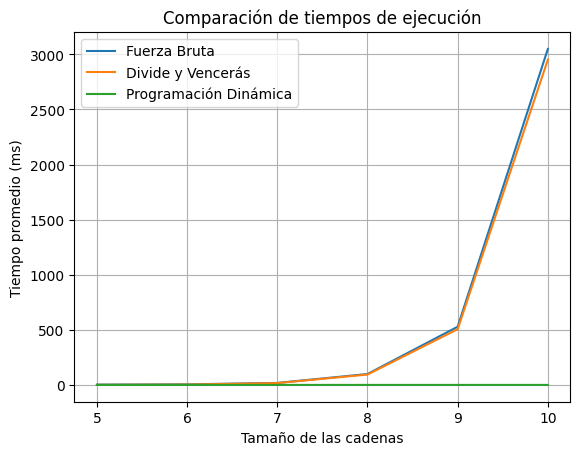

In [67]:
for nombre in algoritmos.keys():
    X = [fila["Tamaño"] for fila in tabla_tiempos]
    Y = [fila[nombre]["Promedio ms"] for fila in tabla_tiempos]
    plt.plot(X, Y, label=nombre)

plt.xlabel("Tamaño de las cadenas")
plt.ylabel("Tiempo promedio (ms)")
plt.title("Comparación de tiempos de ejecución")
plt.legend()
plt.grid()
plt.show()

### 7) Caminos 

In [72]:
pruebas = [
    ("gato", "pato"),
    ("hola", "halo"),
    ("mesa", "casa"),
    ("x"*11, "y"*11)
]

for u, v in pruebas:

    print(f"\n{'='*50}")
    print(f"{u} -> {v}")
    print(f"{'='*50}")

    for nombre, funcion in algoritmos.items():
        inicio = time.time()
        distancia, operaciones = funcion(u, v)
        tiempo_ms = (time.time() - inicio) * 1000

        print(f"\n{nombre} -> Distancia: {distancia} | Tiempo: {round(tiempo_ms,4)} ms")

        for operacion in operaciones:
            print("-", operacion)


gato -> pato

Fuerza Bruta -> Distancia: 1 | Tiempo: 0.1221 ms
- cambiar 'g' por 'p'
- mantener 'a'
- mantener 't'
- mantener 'o'

Divide y Vencerás -> Distancia: 1 | Tiempo: 0.1233 ms
- cambiar 'g' por 'p'
- Mantener 'a'
- Mantener 't'
- Mantener 'o'

Programación Dinámica -> Distancia: 1 | Tiempo: 0.0081 ms
- Cambiar 'g' por 'p'
- Mantener 'a'
- Mantener 't'
- Mantener 'o'

hola -> halo

Fuerza Bruta -> Distancia: 2 | Tiempo: 0.114 ms
- mantener 'h'
- cambiar 'o' por 'a'
- mantener 'l'
- cambiar 'a' por 'o'

Divide y Vencerás -> Distancia: 2 | Tiempo: 0.1171 ms
- Mantener 'h'
- cambiar 'o' por 'a'
- Mantener 'l'
- cambiar 'a' por 'o'

Programación Dinámica -> Distancia: 2 | Tiempo: 0.005 ms
- Mantener 'h'
- Cambiar 'o' por 'a'
- Mantener 'l'
- Cambiar 'a' por 'o'

mesa -> casa

Fuerza Bruta -> Distancia: 2 | Tiempo: 0.1142 ms
- cambiar 'm' por 'c'
- cambiar 'e' por 'a'
- mantener 's'
- mantener 'a'

Divide y Vencerás -> Distancia: 2 | Tiempo: 0.107 ms
- cambiar 'm' por 'c'
- cambiar